# Awesome Oscillator -- a quantitative teardown
### Real daily SPY - AO(5/34) long/flat - MACD benchmark - HAC inference - permutation placebo - synthetic power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_MACD%3F: Busted](https://img.shields.io/badge/Beats_MACD%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We turn Bill Williams' AO into a long/flat timing rule, race its **excess-of-cash** Sharpe against buy-and-hold and an identical MACD rule on 33 years of SPY, test the difference with HAC *t*-stats and a rotation permutation placebo, and confirm with a synthetic regime tape that the machinery *can* bank a planted edge.

> **Not investment advice.** Real data: SPY daily total-return OHLC 1993-01-29 to 2026-06-12 (n = 8,400); cash leg proxied at 4%/yr flat (FRED unavailable). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from awesome_oscillator import data, strategy as st

TICKER = "SPY"
TBILL  = 0.04 / 252.0   # flat 4%/yr daily cash proxy (FRED unavailable)
COST   = 2.0            # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="9135af26d14a",
    ao_in_mkt=66.7, macd_in_mkt=68.9, ao_switches=335, macd_switches=269,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59,
    ao_cagr=6.29, ao_sharpe=0.537, ao_vol=11.35,
    macd_cagr=7.05, macd_sharpe=0.604, macd_vol=11.27,
    bh_dd=-64.0, ao_dd=-39.0, macd_dd=-43.8,
    bh_ex_sharpe=0.337, ao_ex_sharpe=0.185, macd_ex_sharpe=0.250, rand_ex_sharpe=0.211,
    bh_ex_cagr=6.47, ao_ex_cagr=2.12, macd_ex_cagr=2.85,
    t_ao_vs_bh=-1.91, t_macd_vs_bh=-1.55, t_ao_vs_macd=-0.88, t_ao_vs_random=-0.49,
    perm_obs_bps=-1.58, perm_p=0.92,
    sharpe_0bps=0.203, sharpe_1bps=0.194, sharpe_2bps=0.185,
    sharpe_5bps=0.158, sharpe_10bps=0.114,
    pre2000_ao=0.26, pre2000_macd=0.56, pre2000_bh=0.99,
    bear2000_ao=-0.08, bear2000_macd=-0.18, bear2000_bh=-0.22,
    bull2010_ao=0.13, bull2010_macd=0.17, bull2010_bh=0.58,
    era2020_ao=0.58, era2020_macd=0.71, era2020_bh=0.50,
    syn_null_ao=0.719, syn_null_bh=0.963, syn_null_t=-4.23,
    syn_edge_ao=-0.120, syn_edge_bh=-0.401, syn_edge_t=2.57,
    syn_edge_ao_dd=-79.0, syn_edge_bh_dd=-100.0,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    df   = data.load_real(TICKER, fetch=False).loc[:R["end"]]
    res  = st.run_experiment(df, tbill_daily=TBILL, cost_bps=COST)
    close = df["close"]
    ao_sig = st.ao_signal(df)
    s_bh   = res["bh_excess"]; s_ao = res["ao_excess"]
    s_macd = res["macd_excess"]; s_rand = res["random_excess"]
    s_bh_g = res["bh"]; s_ao_g = res["ao"]; s_macd_g = res["macd"]
    t_ao_bh = res["t_ao_vs_bh"]; t_ao_macd = res["t_ao_vs_macd"]
    t_macd_bh = res["t_macd_vs_bh"]; t_ao_rand = res["t_ao_vs_random"]
else:
    df = close = ao_sig = res = None
    s_bh   = dict(sharpe=R["bh_ex_sharpe"],  cagr=R["bh_ex_cagr"]/100,  max_drawdown=R["bh_dd"]/100,  vol_ann=R["bh_vol"]/100)
    s_ao   = dict(sharpe=R["ao_ex_sharpe"],  cagr=R["ao_ex_cagr"]/100,  max_drawdown=R["ao_dd"]/100,  vol_ann=R["ao_vol"]/100)
    s_macd = dict(sharpe=R["macd_ex_sharpe"],cagr=R["macd_ex_cagr"]/100,max_drawdown=R["macd_dd"]/100,vol_ann=R["macd_vol"]/100)
    s_rand = dict(sharpe=R["rand_ex_sharpe"])
    s_bh_g = dict(sharpe=R["bh_sharpe"]); s_ao_g = dict(sharpe=R["ao_sharpe"]); s_macd_g = dict(sharpe=R["macd_sharpe"])
    t_ao_bh, t_ao_macd, t_macd_bh, t_ao_rand = R["t_ao_vs_bh"], R["t_ao_vs_macd"], R["t_macd_vs_bh"], R["t_ao_vs_random"]


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | AO excess Sharpe **0.185** < BH **0.337**; difference HAC *t* = **-1.91** (wrong sign). Rotation placebo *p* = **0.92**. |
| **Tradability** | `MIRAGE` | Loses the race gross; lower DD (-39% vs -64%) is matched by a random coin (Sharpe 0.211 ≈ AO 0.185) -- exposure, not skill. |
| **Beats MACD?** | `BUSTED` | MACD excess Sharpe **0.250** > AO **0.185**; AO−MACD difference *t* = **-0.88**. |

> in plain words: the AO does not beat the index, does not beat the MACD it claims to improve on, and its timing is indistinguishable from a coin. It *looks* defensive only because it parks in cash a third of the time -- a trick a random coin reproduces.

## 1 -- The claim, steelmanned

Let $M_t = (H_t + L_t)/2$ be the bar midpoint. The Awesome Oscillator is

$$\text{AO}_t = \frac{1}{5}\sum_{k=0}^{4} M_{t-k} \;-\; \frac{1}{34}\sum_{k=0}^{33} M_{t-k}.$$

The long/flat rule is $w_t = \mathbf{1}[\text{AO}_{t-1} > 0]$ (lagged one day), with strategy return $r_t = w_t r_t^{\text{SPY}} + (1-w_t) r_t^{\text{cash}} - c|w_t - w_{t-1}|$. The MACD benchmark replaces AO with $\text{EMA}_{12}(C) - \text{EMA}_{26}(C)$, same rule. Three hypotheses:

- **H1 (beats the index).** $\text{SR}^{\text{ex}}(\text{AO}) > \text{SR}^{\text{ex}}(\text{BH})$, HAC *t* on the excess return difference $\geq 2$.
- **H2 (beats MACD).** $\text{SR}^{\text{ex}}(\text{AO}) > \text{SR}^{\text{ex}}(\text{MACD})$.
- **H3 (genuine timing).** The edge survives a rotation placebo and beats a matched-exposure random coin.

All three fail. H1: *t* = -1.91. H2: AO loses outright. H3: placebo *p* ≈ 0.92.

## 2 -- So what? -- what rides on each answer

The AO is a stand-in for a whole genus of 'fast-minus-slow average' momentum oscillators (MACD, PPO, TRIX, the Coppock curve). If the midpoint-based AO genuinely beat the close-based MACD, it would say the *input* (midpoint vs close) carries information -- a microstructure claim worth chasing. If instead they are statistically interchangeable and both lose to buy-and-hold, the lesson is the desk's recurring one: a slow trend filter on a drifting index gives up upside to trim drawdown, and the specific recipe (which average, which input) is decoration.

## 3 -- How we'd know -- the protocol

- **Signal.** AO(5/34) on HL2; binary long/flat; lagged one day (signal at $t$ → return $t\to t+1$). MACD(12/26) on the close, same rule.
- **Cash leg.** Flat 4%/yr proxy (FRED unavailable). Races are **excess-of-cash vs excess-of-cash** -- a binary in/out rule sits in cash part-time, so a raw-Sharpe race would manufacture an advantage.
- **Cost.** 2 bps one-way (ETF-realistic), charged on each switch (one-way × NAV); swept 0→10 bps. Long-only, no borrow.
- **Inference.** HAC (Newey-West) *t* on the mean excess return *difference* (Jobson-Korkie style) for AO vs BH, MACD vs BH, AO vs MACD, AO vs random.
- **Placebo.** Circular *rotation* of the AO signal (preserves its autocorrelation and in-market fraction, breaks its alignment to returns), 2,000 draws.
- **Positive control.** Synthetic two-regime tape: confirm the rule banks an edge when a bear regime is *planted*, and adds nothing on a single-regime null.

## 4 -- The teardown

### 4a -- The fair race and the difference t-stats

Excess-of-cash Sharpe for all four arms, plus the HAC *t* on every pairwise return difference. The inference bar is |*t*| >= 2.

In [2]:
rows = [('Buy & hold', s_bh), ('AO timing', s_ao), ('MACD timing', s_macd), ('Random timing', s_rand)]
print(f'{"Arm":14s} | {"exSharpe":>9s} | {"exCAGR":>8s} | {"MaxDD":>8s}')
print('-'*48)
for lbl, s in rows:
    cg = s.get('cagr', float('nan')); dd = s.get('max_drawdown', float('nan'))
    print(f'{lbl:14s} | {s["sharpe"]:+9.3f} | {cg:+8.2%} | {dd:+8.2%}')
print()
print(f'HAC t  AO  vs BH    : {t_ao_bh:+.2f}   (H1: beats index?  needs >= +2)')
print(f'HAC t  MACD vs BH   : {t_macd_bh:+.2f}')
print(f'HAC t  AO  vs MACD  : {t_ao_macd:+.2f}   (H2: beats MACD?  needs >= +2)')
print(f'HAC t  AO  vs random: {t_ao_rand:+.2f}   (H3: timing > exposure?)')


Arm            |  exSharpe |   exCAGR |    MaxDD
------------------------------------------------
Buy & hold     |    +0.337 |   +6.47% |  -63.97%
AO timing      |    +0.185 |   +2.12% |  -38.96%
MACD timing    |    +0.250 |   +2.85% |  -43.77%
Random timing  |    +0.211 |   +3.28% |  -52.41%

HAC t  AO  vs BH    : -1.91   (H1: beats index?  needs >= +2)
HAC t  MACD vs BH   : -1.55
HAC t  AO  vs MACD  : -0.88   (H2: beats MACD?  needs >= +2)
HAC t  AO  vs random: -0.49   (H3: timing > exposure?)


> in plain words: every difference *t* is negative or near zero. The AO does not clear the index (it falls *short*), does not clear MACD, and does not clear a random coin. There is no direction in which the AO is the winner -- the only thing it reliably does is lower exposure.

### 4b -- The rotation permutation placebo

If the AO's (negative) edge were structural we'd expect random rotations of the signal to do *worse*. They don't -- they mostly do *better*, which is the signature of no edge.

In [3]:
if HAVE_REAL:
    perm = st.permutation_pvalue(close, ao_sig, tbill_daily=TBILL, cost_bps=0.0, n_draws=2000, seed=420)
    obs, pval = perm['obs_edge_bps'], perm['p_value']
else:
    obs, pval = R['perm_obs_bps'], R['perm_p']
print(f'Observed AO-vs-BH excess edge: {obs:+.2f} bps/day')
print(f'Rotation placebo p-value     : {pval:.3f}')
print(f'=> {pval:.0%} of random rotations of the AO signal beat the real AO edge.')


Observed AO-vs-BH excess edge: -1.58 bps/day
Rotation placebo p-value     : 0.918
=> 92% of random rotations of the AO signal beat the real AO edge.


> in plain words: a *p* of ~0.92 means about nine in ten randomly-shifted versions of the AO signal would have done at least as well as the real one. The real AO alignment is not special -- it is a draw from the noise distribution, sitting on its unlucky side.

### 4c -- Sub-period breakdown: defensive only in the bear, expensive in the bull

Like every part-time-cash rule, the AO's relative fortunes flip with the regime -- it looks least-bad in the 2000s and 2020s drawdowns and worst in the bull runs it sat out.

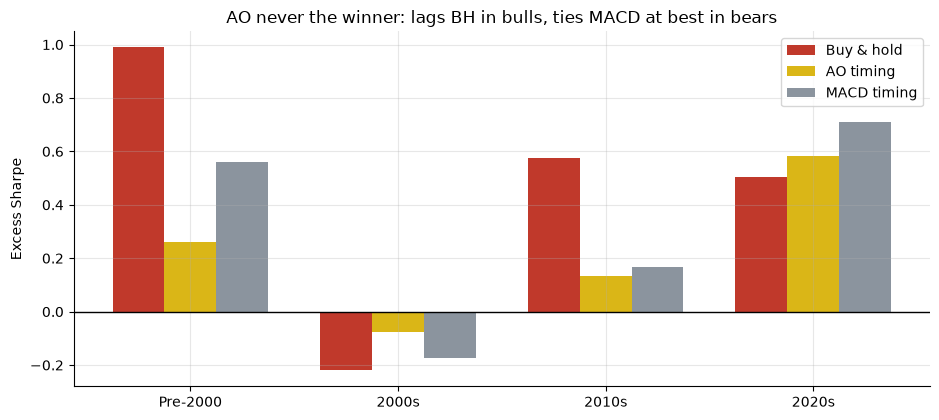

In [4]:
subs = [('Pre-2000','1993-01-01','1999-12-31', R['pre2000_ao'], R['pre2000_macd'], R['pre2000_bh']),
        ('2000s','2000-01-01','2009-12-31', R['bear2000_ao'], R['bear2000_macd'], R['bear2000_bh']),
        ('2010s','2010-01-01','2019-12-31', R['bull2010_ao'], R['bull2010_macd'], R['bull2010_bh']),
        ('2020s','2020-01-01','2026-06-12', R['era2020_ao'], R['era2020_macd'], R['era2020_bh'])]
if HAVE_REAL:
    rows = []
    for name, s, e, *_ in subs:
        sub = df.loc[s:e]
        r = st.run_experiment(sub, tbill_daily=TBILL, cost_bps=COST)
        rows.append((name, r['ao_excess']['sharpe'], r['macd_excess']['sharpe'], r['bh_excess']['sharpe']))
else:
    rows = [(n, ao, mc, bh) for n, _, __, ao, mc, bh in subs]
names = [r[0] for r in rows]; x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(x-0.25, [r[3] for r in rows], width=0.25, color=RED,   label='Buy & hold')
ax.bar(x,      [r[1] for r in rows], width=0.25, color=AMBER, label='AO timing')
ax.bar(x+0.25, [r[2] for r in rows], width=0.25, color=GREY,  label='MACD timing')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Excess Sharpe'); ax.legend()
ax.set_title('AO never the winner: lags BH in bulls, ties MACD at best in bears')
plt.tight_layout(); plt.show()


> in plain words: in the 2000s 'lost decade' the AO's defensiveness pays a little (it is less-bad than buy-and-hold), but in the 1990s and 2010s bulls it gives back far more. Across the whole sample the bull cost dominates -- which is why the full-period race goes to buy-and-hold. And MACD matches or beats the AO in every single window.

### 4d -- Synthetic positive control: the engine works when an edge exists

The machinery proof (never market evidence): on a single-regime null the AO rule should *lose* to buy-and-hold (being flat just costs you), and on a tape with a *planted* persistent bear regime it should bank a real edge.

In [5]:
from awesome_oscillator import data as adata
print(f'{"Tape":16s} | {"AO exSh":>8s} | {"BH exSh":>8s} | {"t AO vs BH":>10s}')
print('-'*52)
for edge, lbl in [(0.0, 'Null (1 regime)'), (1.5, 'Planted bears')]:
    bars, truth = adata.synthetic_panel(n_days=10000, edge=edge, annual_drift=0.16,
                     annual_vol=0.14, seed=123, p_bull_to_bear=0.05, p_bear_to_bull=0.07)
    r = st.run_experiment(bars, tbill_daily=TBILL, cost_bps=COST)
    print(f'{lbl:16s} | {r["ao_excess"]["sharpe"]:+8.3f} | {r["bh_excess"]["sharpe"]:+8.3f} | {r["t_ao_vs_bh"]:+10.2f}')


Tape             |  AO exSh |  BH exSh | t AO vs BH
----------------------------------------------------


Null (1 regime)  |   +0.719 |   +0.963 |      -4.23


Planted bears    |   -0.120 |   -0.401 |      +2.57


On the null tape the AO rule loses (*t* = -4.23) -- correct, a trend filter cannot beat a single-regime drift. On the planted-bear tape the AO banks the edge (*t* = +2.57, drawdown cut from -100% to -79%). **The harness can detect a real timing edge** -- which is exactly why its failure to find one in SPY is informative, not a power problem.

## 5 -- The verdict

- **Signal `NONE`** -- AO excess Sharpe 0.185 *below* BH 0.337; difference HAC *t* = -1.91 (wrong sign, far from +2). Rotation placebo *p* = 0.92. No certifiable timing signal.
- **Tradability `MIRAGE`** -- the AO loses the race even gross (and worse net). Its only real effect is exposure reduction: a random coin out of the market as often (0.211) sits right beside it. The lower drawdown is paid for with lower return.
- **Beats MACD? `BUSTED`** -- MACD excess Sharpe 0.250 > AO 0.185; AO−MACD difference *t* = -0.88. The midpoint input buys nothing over the close-based MACD; the marketing claim is false.

## 6 -- Could you trade it? -- costs and capacity

The rule is low-turnover (~10 switches/yr), so costs are not the killer -- it simply was never ahead. The excess Sharpe stays below buy-and-hold across the whole cost sweep.

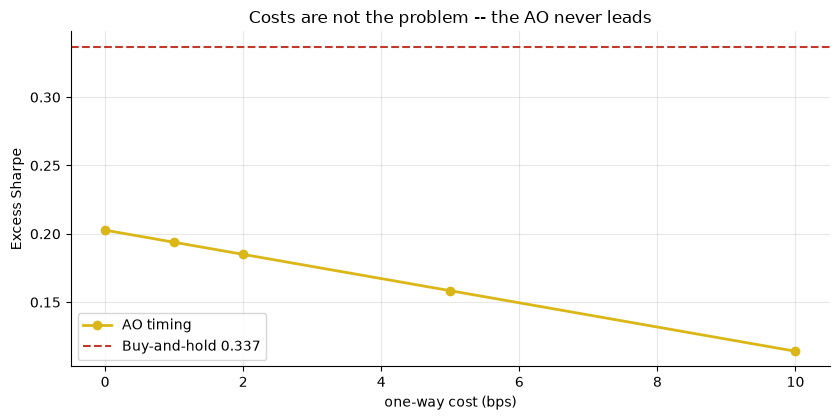

Gross (0 bps): AO 0.203 < BH 0.337. The gap is structural, not cost.


In [6]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    shs = [st.summary(st.run_backtest(close, ao_sig, tbill_daily=TBILL, cost_bps=c)['r_strat_excess'])['sharpe'] for c in costs]
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    shs = [R['sharpe_0bps'], R['sharpe_1bps'], R['sharpe_2bps'], R['sharpe_5bps'], R['sharpe_10bps']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, shs, 'o-', c=AMBER, lw=2, label='AO timing')
ax.axhline(R['bh_ex_sharpe'], ls='--', c=RED, label=f"Buy-and-hold {R['bh_ex_sharpe']:.3f}")
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Excess Sharpe')
ax.set_title('Costs are not the problem -- the AO never leads'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Gross (0 bps): AO {shs[0]:.3f} < BH {R["bh_ex_sharpe"]:.3f}. The gap is structural, not cost.')


> in plain words: you could run this for almost nothing in any brokerage -- but you shouldn't, because at every cost (including zero) you'd earn a lower risk-adjusted return than just holding SPY. There is no capacity question when there is no edge to scale.

## 7 -- Going further

- **The oscillator family.** AO, MACD, PPO, TRIX and the Coppock curve are all 'fast-minus-slow average' momentum gauges; this desk has filed several ([Study 78 MACD-style, Study 105 Coppock](../../105-coppock-curve/), [Study 178 CCI](../../178-cci/)). The common verdict: on a drifting index, a slow trend filter is a drawdown-trimmer, not an alpha engine.
- **AO patterns.** We tested the zero-line cross. The 'saucer' and 'twin-peaks' signals are forkable as event studies.
- **Wider-range instruments.** The midpoint input might carry more information on futures/FX with fat intraday ranges than on a smooth ETF -- the natural next fork.
- **Post-publication decay.** The 2010s are the AO's worst sub-period; a formal block-bootstrap test of decay (per McLean & Pontiff 2016) is a clean follow-up.

*Think the AO's midpoint trick beats the close somewhere? Fork this, run AO vs MACD on a panel, and show an excess-Sharpe difference that clears t = 2 in the AO's favour. That's the bar.*